<h2 style='color:purple' align='center'>Build our first neural network in Keras for image classification problem</h2>

**We will use keras fashion MNIST dataset. This consist of 60000 28X28 pixel images and 10000 test images, these images are classified in one of the 10 categories shown below**

<img src="slide1.png" />

In [10]:
import keras
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [12]:
X_train.shape

(60000, 28, 28)

In [13]:
X_test.shape

(10000, 28, 28)

In [14]:
y_train[0]

np.uint8(9)

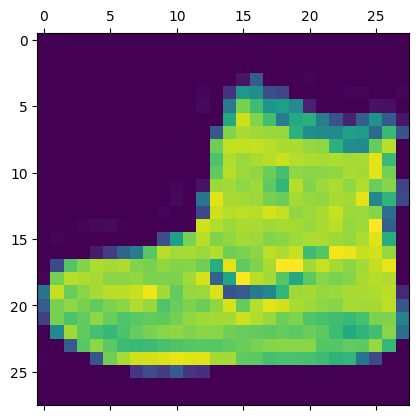

In [15]:
plt.matshow(X_train[0])

In [34]:
def plot_sample(index):
    plt.figure(figsize = (30,5))
    plt.imshow(X_train[index])

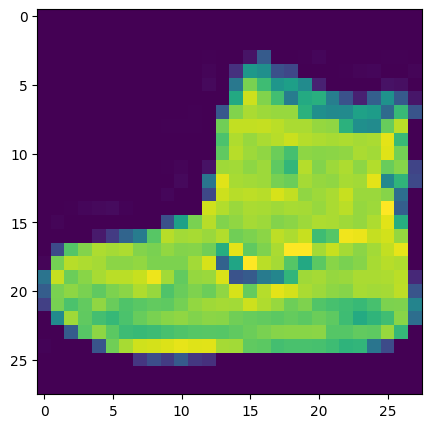

In [35]:
plot_sample(0)

<h3 style='color:purple'>Normalize training data before training the neural net</h3>

In [18]:
X_train = X_train/255

In [19]:
X_test = X_test/255

<h3 style='color:purple'>Now build the Sequential Model and add layers into it</h3>

In [20]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy", 
              optimizer="adam",
              metrics=["accuracy"])
              
model.fit(X_train, y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8207 - loss: 0.5089


In [23]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8460 - loss: 0.4346


[0.4345930516719818, 0.8460000157356262]

In [24]:
yp = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step


In [25]:
yp[0]

array([4.2029136e-05, 4.4860890e-06, 3.2220094e-05, 3.2673379e-05,
       1.6434848e-05, 2.5135130e-01, 4.4628985e-05, 1.5091126e-01,
       5.1212492e-03, 5.9244370e-01], dtype=float32)

In [26]:
class_labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [27]:
class_labels[np.argmax(yp[0])]

'Ankle boot'